# 🚀 Day 35: Decision Trees for Regression

---

## Objectives:

- Understand **how Decision Trees can be used for Regression**.
- Implement **Regression Trees** on a real-world dataset.
- Predict **continuous values** using Decision Trees.
- Visualize the **Decision Tree structure** and feature importance.
- Evaluate model performance using **R², MAE, and RMSE**.

---

## 1. Introduction to Decision Trees for Regression

### 1.1 What are Decision Trees for Regression?

A **Decision Tree Regressor** is a tree-like model used to predict continuous values. Unlike classification trees, it splits the data to minimize the error in predicting numerical outcomes.

### 1.2 Why Use Decision Trees for Regression?

✅ **Handles non-linear relationships**

✅ **Interpretable and easy to visualize**

✅ **No need for feature scaling**

✅ **Can capture complex patterns**

---

## 2. Dataset Overview

We will use the **Insurance Dataset**, which contains information about individuals and their medical insurance costs.

**Features:**
- **age** (Age of the individual)
- **sex** (Gender: male or female)
- **bmi** (Body Mass Index)
- **children** (Number of children covered by insurance)
- **smoker** (Smoker status: yes or no)
- **region** (Region of residence)

**Target:**
- **charges** (Medical insurance cost in USD)

---

## 3. Data Loading and Exploration

---

In [1]:
#Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.tree import plot_tree
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [2]:
#Load the dataset
df = pd.read_csv('insurance.csv')

In [3]:
#Display few rows
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [4]:
#display summary of dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


## 4. EDA

---

In [5]:
#check for missing values
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

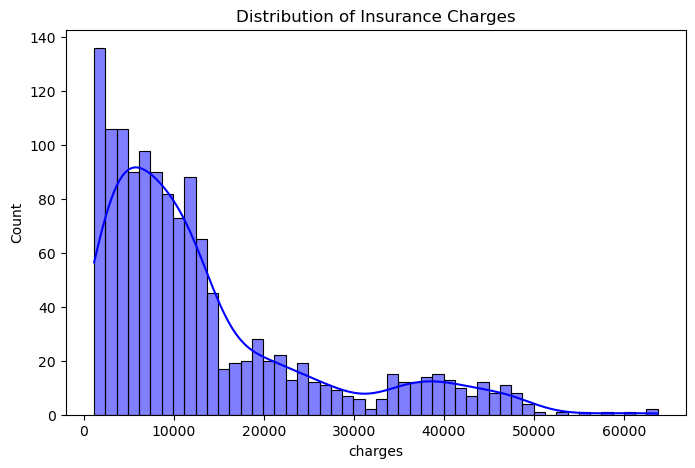

In [7]:
#Distribution of target variable
plt.figure(figsize=(8,5))
sns.histplot(df['charges'], bins=50, kde=True, color='blue')
plt.title('Distribution of Insurance Charges')
plt.show()

---

## 5. Data Preprocessing

---

In [8]:
# Define Features and Target Variable
X = df.drop(columns=['charges'])
y = df['charges']

In [16]:
#OneHot Encoding for categorical variables
categorical_features = ['sex', 'smoker', 'region']
numeric_features = ['age', 'bmi', 'children']
preprocessor = ColumnTransformer([('onehot', OneHotEncoder(drop='first'),
                                   categorical_features)],
                                 force_int_remainder_cols=False)

In [17]:
#Split dataset
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)


---

## 6. Training a Decision Tree Regressor

---

In [44]:
#Decision Tree model
model = Pipeline([('preprocessor', preprocessor),
                  ('regressor', DecisionTreeRegressor(max_depth=4, random_state=42))])

In [45]:
#Train the model
model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(force_int_remainder_cols=False,
                                   transformers=[('onehot',
                                                  OneHotEncoder(drop='first'),
                                                  ['sex', 'smoker',
                                                   'region'])])),
                ('regressor',
                 DecisionTreeRegressor(max_depth=4, random_state=42))])

---

## 7. Model Evaluation

---

In [46]:
#Predictions
y_pred = model.predict(X_test)

In [47]:
#Calculate evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_absolute_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f'MAE: {mae:.2f}')
print(f'RMSE: {rmse:.2f}')
print(f'R2 Score: {r2:.2f}')

MAE: 5597.23
RMSE: 74.81
R2 Score: 0.65


---

## 8. Visualization of Decision Tree

---

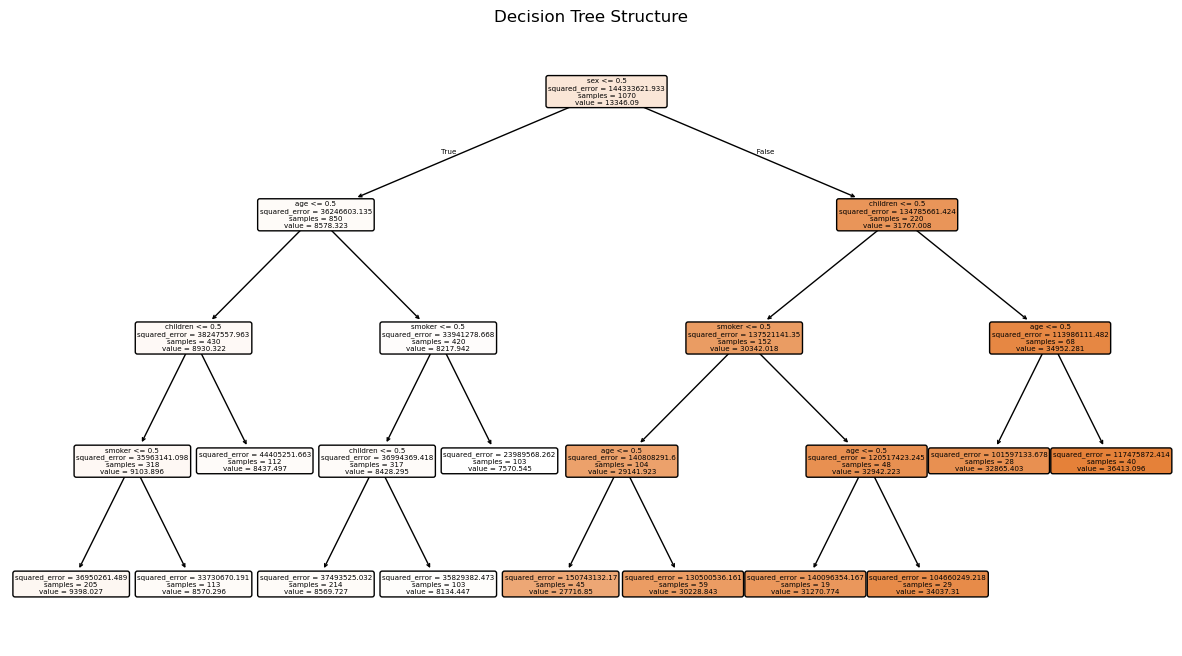

In [48]:
#Plot Decision Tree
plt.figure(figsize=(15,8))
plot_tree(model.named_steps['regressor'], feature_names=X.columns, filled=True, rounded=True)
plt.title('Decision Tree Structure')
plt.show()

---

## 9. Feature Importance

---

In [49]:
# Extract the feature names from the pipeline
preprocessor = model.named_steps['preprocessor']
feature_names_after_preprocessing = preprocessor.get_feature_names_out()

In [54]:
#Extract Decision Tree model from the pipeline
tree_model =model.named_steps['regressor']

In [57]:
#Get feature importance
feature_importance = tree_model.feature_importances_

In [59]:
print(len(feature_importance), len(feature_names_after_preprocessing))

5 5


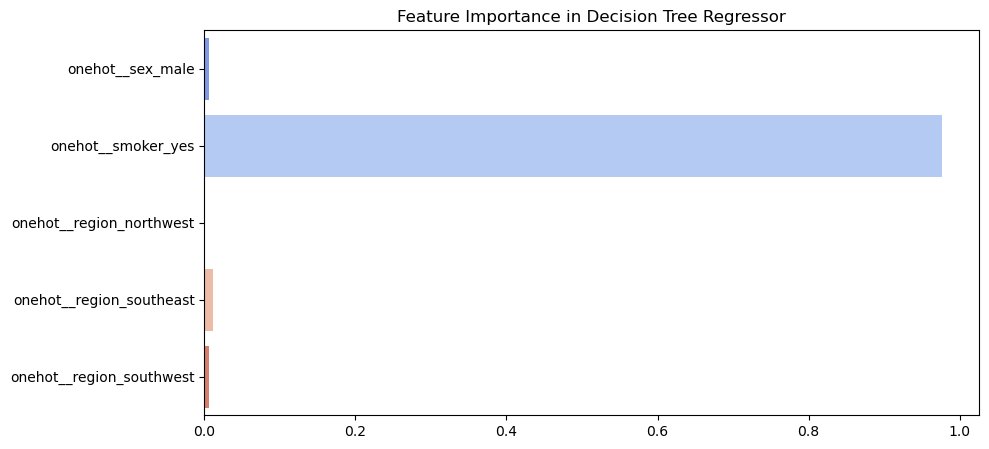

In [64]:
#Plot feature Importance
plt.figure(figsize=(10,5))
sns.barplot(x=feature_importance, y=feature_names_after_preprocessing,hue=feature_names_after_preprocessing, palette='coolwarm', legend=False)
plt.title('Feature Importance in Decision Tree Regressor')
plt.show()

---

## 10. Conclusion

---

✅ Implemented **Decision Trees for Regression**.

✅ Predicted **insurance charges** using tree-based modeling.

✅ **Visualized the decision tree** and analyzed feature importance.

✅ Achieved a good model fit with reasonable error metrics.

🚀 **This concludes Day 35 of our ML journey!** 🚀